In [ ]:
#!pip install torch

In [1]:
# The dataset needs to be on google drive to work
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import shutil
import torch
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from PIL import Image
from pathlib import Path
from albumentations import *
from torchvision import transforms, datasets
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import KFold

In [3]:
def build_data_registry(root_dir="."):
    folders = [
        'target_train', 'target_dev',
        'non_target_train', 'non_target_dev'
    ]

    records = []

    for folder in folders:
        folder_path = os.path.join(root_dir, folder)
        if not os.path.exists(folder_path):
            continue

        current_label = 1 if folder.startswith('target') else 0
        files = os.listdir(folder_path)
        images = [f for f in files if f.endswith('.png')]

        for img_name in images:
            parts = img_name.split('_')
            identity = parts[0]
            session = parts[1]

            base_name = img_name.replace('.png', '')
            wav_name = base_name + '.wav'
            wav_path = os.path.join(folder_path, wav_name)

            records.append({
                'id': identity,
                'session': session,
                'label': current_label,
                'is_dev': 'dev' in folder,
                'image_path': os.path.join(folder_path, img_name),
                'audio_path': wav_path if os.path.exists(wav_path) else None,
                'original_folder': folder
            })

    df = pd.DataFrame(records)
    return df

os.chdir('/content/drive/MyDrive/SUR') # Change the current working directory to project folder
registry_df = build_data_registry()
registry_df.to_csv("data_registry.csv", index=False)

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class BiometricDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(row['label'], dtype=torch.long)
        return image, label

class FaceCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveMaxPool2d((4,4)),
            nn.Dropout(0.3)
        )
        self.classifier = nn.Sequential(
            nn.Linear(64 * 4 * 4, 128), nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(80, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.8)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet mean and std
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet mean and std
])

Using device: cuda


In [9]:
df = pd.read_csv('data_registry.csv')

# Devide based on target and strangers
target_df = df[df['id'] == 'm431'].copy()
stranger_df = df[df['id'] != 'm431'].copy()

# Get unique sessions for target and unique IDs for strangers
target_sessions = sorted(target_df['session'].unique())
stranger_ids = sorted(stranger_df['id'].unique())

# Use of KFold on the stranger IDs to ensure they never overlap
kf_strangers = KFold(n_splits=3, shuffle=True, random_state=42)
stranger_id_splits = list(kf_strangers.split(stranger_ids))

all_fold_accuracies = []

for fold in range(3):
    print(f"Fold: {fold}")

    # Target split by session
    val_sess = target_sessions[fold % len(target_sessions)]
    t_train = target_df[target_df['session'] != val_sess]
    t_val = target_df[target_df['session'] == val_sess]

    # Stranger split by ID
    train_idx_ids, val_idx_ids = stranger_id_splits[fold]
    train_ids = [stranger_ids[i] for i in train_idx_ids]
    val_ids = [stranger_ids[i] for i in val_idx_ids]

    s_train = stranger_df[stranger_df['id'].isin(train_ids)]
    s_val = stranger_df[stranger_df['id'].isin(val_ids)]

    # Combine into final dataframes
    train_df = pd.concat([t_train, s_train])
    val_df = pd.concat([t_val, s_val])

    labels = train_df['label'].values
    class_sample_count = np.array([len(labels) - labels.sum(), labels.sum()])
    weights = 1. / class_sample_count
    sample_weights = weights[labels]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

    # Dataloader and training
    train_loader = DataLoader(
        BiometricDataset(train_df, train_transform),
        batch_size=8,
        sampler=sampler
    )
    val_loader = DataLoader(
        BiometricDataset(val_df, val_transform),
        batch_size=8,
        shuffle=False
    )

    model = FaceCNN(num_classes=2).to(device)

    optimizer = optim.SGD(
        model.parameters(),
        lr=0.005,
        momentum=0.9,
        nesterov=True
    )

    criterion = nn.CrossEntropyLoss()

    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=0.005,
        steps_per_epoch=len(train_loader),
        epochs=40
    )

    best_val_acc = 0

    # 40 epochs
    for epoch in range(40):
        model.train()
        epoch_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()
            scheduler.step()

            epoch_loss += loss.item()

        # Validation
        model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                _, predicted = torch.max(outputs, 1)

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        # Accuracy
        correct = (np.array(all_preds) == np.array(all_labels)).sum()
        acc = 100 * correct / len(all_labels)

        if acc > best_val_acc:
            best_val_acc = acc
            torch.save(model.state_dict(), f'best_model_fold{fold}.pth')

            best_preds = all_preds
            best_labels = all_labels

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:02d} | Train Loss: {epoch_loss/len(train_loader):.4f} | Val Acc: {acc:.2f}%")

    # Summary
    print(f"\nFold {fold} report")
    print(f"Best Accuracy: {best_val_acc:.2f}%")

    cm = confusion_matrix(best_labels, best_preds)

    print("\nConfusion Matrix:")
    print(f"True Neg (Stranger Rejected): {cm[0,0]}")
    print(f"False Pos (Stranger Allowed): {cm[0,1]}")
    print(f"False Neg (Target Rejected) : {cm[1,0]}")
    print(f"True Pos (Target Allowed)   : {cm[1,1]}")

    print("\nClassification Report:")
    print(classification_report(best_labels, best_preds, target_names=['Stranger', 'Target']))

    all_fold_accuracies.append(best_val_acc)

print(f"\nFinal Cross-validation mean accuracy: {np.mean(all_fold_accuracies):.2f}%")

Fold: 0
Epoch 10 | Train Loss: 0.1924 | Val Acc: 90.24%
Epoch 20 | Train Loss: 0.1008 | Val Acc: 98.78%
Epoch 30 | Train Loss: 0.2449 | Val Acc: 97.56%
Epoch 40 | Train Loss: 0.1348 | Val Acc: 97.56%

Fold 0 report
Best Accuracy: 100.00%

Confusion Matrix:
True Neg (Stranger Rejected): 72
False Pos (Stranger Allowed): 0
False Neg (Target Rejected) : 0
True Pos (Target Allowed)   : 10

Classification Report:
              precision    recall  f1-score   support

    Stranger       1.00      1.00      1.00        72
      Target       1.00      1.00      1.00        10

    accuracy                           1.00        82
   macro avg       1.00      1.00      1.00        82
weighted avg       1.00      1.00      1.00        82

Fold: 1
Epoch 10 | Train Loss: 0.3052 | Val Acc: 86.76%
Epoch 20 | Train Loss: 0.1575 | Val Acc: 82.35%
Epoch 30 | Train Loss: 0.1286 | Val Acc: 85.29%
Epoch 40 | Train Loss: 0.0913 | Val Acc: 85.29%

Fold 1 report
Best Accuracy: 88.24%

Confusion Matrix:
True N

Successfully loaded 3 models into the ensemble.
Top Row: Target Samples | Bottom Row: Non-target Samples


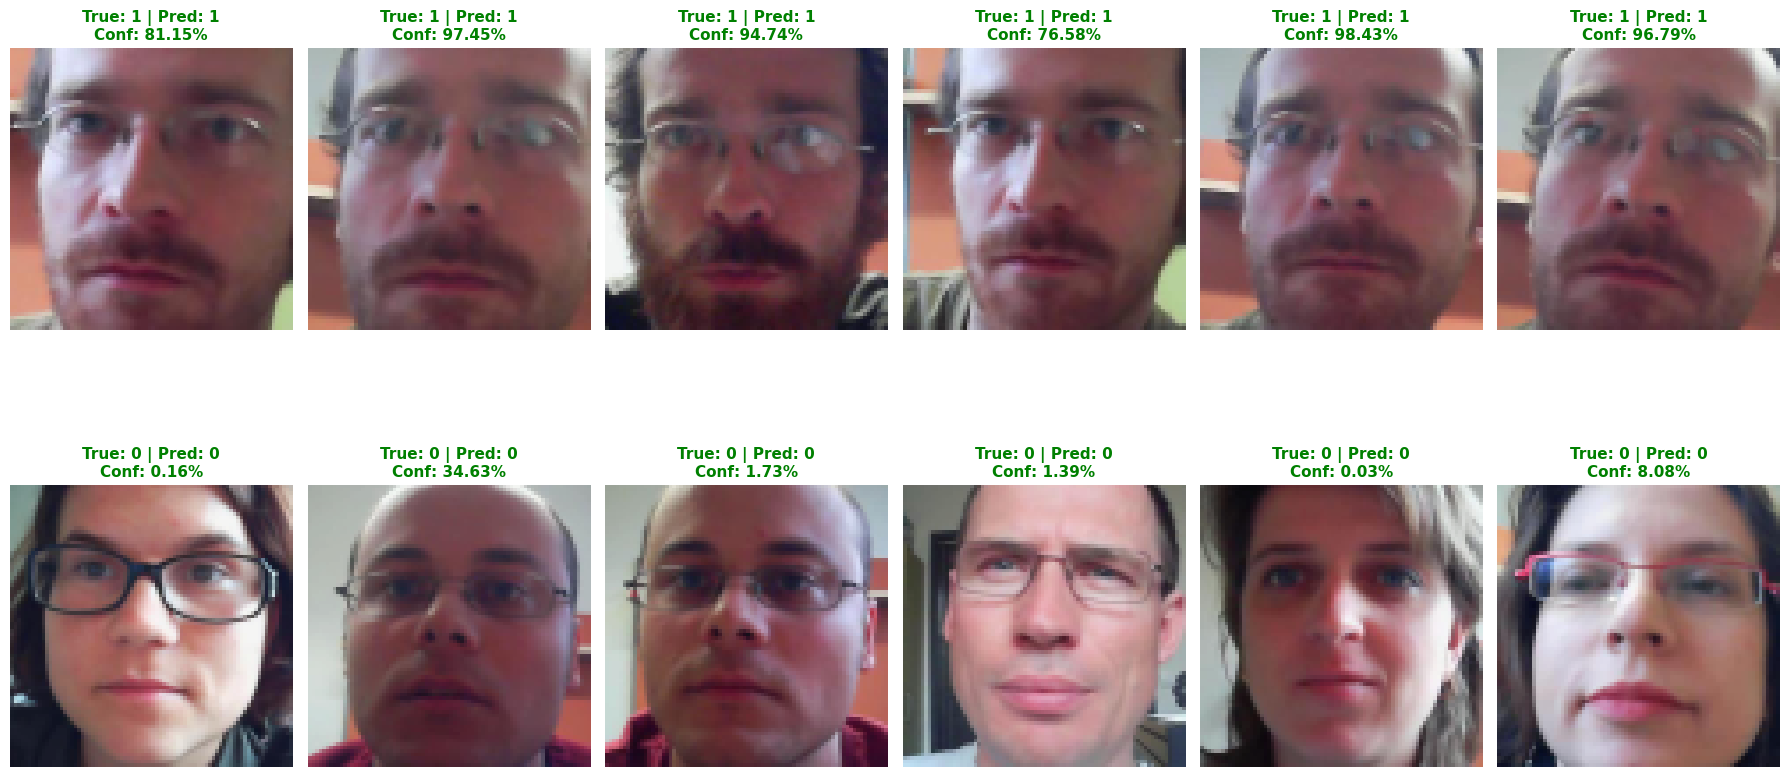

In [11]:
# Helper function for plots of samples
def plot_sample(dataset, idx, ax_obj, threshold):
    image, label = dataset[int(idx)]
    input_tensor = image.unsqueeze(0).to(device)

    # Ensemble Probability
    total_prob = 0
    with torch.no_grad():
        for m in models:
            output = m(input_tensor)
            total_prob += torch.softmax(output, dim=1)[0][1].item()
    avg_prob = total_prob / len(models)

    pred_label = 1 if avg_prob > threshold else 0
    true_label = label.item()

    # Prepare Image for Display
    img = image.permute(1, 2, 0).cpu().numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    ax_obj.imshow(img)
    title_color = 'green' if pred_label == true_label else 'red'
    ax_obj.set_title(f"True: {true_label} | Pred: {pred_label}\nConf: {avg_prob:.2%}",
                      color=title_color, fontsize=11, fontweight='bold')
    ax_obj.axis('off')

def visualize_comparative_results(dataset, num_samples=5, threshold=0.5):
    target_indices = [i for i, (img, lbl) in enumerate(dataset) if lbl == 1]
    stranger_indices = [i for i, (img, lbl) in enumerate(dataset) if lbl == 0]

    t_samples = np.random.choice(target_indices, min(num_samples, len(target_indices)), replace=False)
    s_samples = np.random.choice(stranger_indices, min(num_samples, len(stranger_indices)), replace=False)

    fig, axes = plt.subplots(2, num_samples, figsize=(18, 10))

    # Target Samples
    print("Top Row: Target Samples | Bottom Row: Non-target Samples")
    for i in range(num_samples):
        plot_sample(dataset, t_samples[i], axes[0, i], threshold)

    # Stranger Samples
    for i in range(num_samples):
        plot_sample(dataset, s_samples[i], axes[1, i], threshold)

    plt.tight_layout()
    plt.show()

# Re-assembling the models
model_paths = ['best_model_fold0.pth', 'best_model_fold1.pth', 'best_model_fold2.pth']
models = []

for path in model_paths:
    m = FaceCNN(num_classes=2).to(device)
    m.load_state_dict(torch.load(path, weights_only=True, map_location=device))
    m.eval()
    models.append(m)

print(f"Successfully loaded {len(models)} models into the ensemble.")

full_df = pd.read_csv('data_registry.csv')
eval_dataset = BiometricDataset(full_df, transform=val_transform)

# Threshold set to 0.4, because the confident of target was pretty low, where non-target mostly achieve under 10 %
visualize_comparative_results(eval_dataset, num_samples=6, threshold=0.4)

In [12]:
def generate_ensemble_output(models, image_dir, output_file, transform, device, threshold=0.4):
    for m in models:
        m.eval()

    results = []

    image_files = sorted([f for f in os.listdir(image_dir)
                          if os.path.isfile(os.path.join(image_dir, f))
                          and f.lower().endswith('.png')])

    print(f"Processing {len(image_files)} images from {image_dir}...")

    with torch.no_grad():
        for img_file in image_files:
            img_path = os.path.join(image_dir, img_file)
            image = Image.open(img_path).convert('RGB')
            image = transform(image).unsqueeze(0).to(device)

            total_prob = 0
            # Calculate the sum of probabilities for Class 1 (Target)
            for m in models:
                output = m(image)
                prob = torch.softmax(output, dim=1)[0][1].item()
                total_prob += prob

            avg_prob = total_prob / len(models)

            # Evaluation based on threshold 0.4, for better results for target
            pred_class = 1 if avg_prob > threshold else 0

            filename = Path(img_file).stem
            line = f"{filename} {avg_prob:.10f} {pred_class}"
            results.append(line)

    with open(output_file, 'w') as f:
        f.write("\n".join(results))
    print(f"Results saved to {output_file}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_paths = ['best_model_fold0.pth', 'best_model_fold1.pth', 'best_model_fold2.pth']
loaded_models = []

for path in model_paths:
    m = FaceCNN(num_classes=2).to(device)
    m.load_state_dict(torch.load(path))
    loaded_models.append(m)

# 2. Run the generator
generate_ensemble_output(
    models=loaded_models,
    image_dir='./Eval_data/eval',
    output_file='cnn_image_results.txt',
    transform=val_transform,
    device=device,
    threshold=0.4
)

Processing 1346 images from ./Eval_data/eval...
Results saved to cnn_image_results.txt
